In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
np.random.seed(42)
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import pandas as pd

if 'train_df' not in globals():
    train_df = pd.read_parquet("train_preprocessed.parquet")
train_with_cluster = train_df.copy()

print("=== Cluster 1 Demand Distribution ===")
for cid in [0, 1]:
    mask = train_with_cluster["Demand_Cluster"] == cid
    demand = train_with_cluster.loc[mask, "Order_Demand"]
    zero_rate = (demand == 0).mean() * 100
    print(f"\nCluster {cid}:")
    print(f"  Rows       : {mask.sum():,}")
    print(f"  Zero rate  : {zero_rate:.1f}%")
    print(f"  Mean       : {demand.mean():.1f}")
    print(f"  Median     : {demand.median():.1f}")
    print(f"  P90        : {demand.quantile(0.9):.1f}")
    print(f"  P99        : {demand.quantile(0.99):.1f}")
    print(f"  Max        : {demand.max():.1f}")

=== Cluster 1 Demand Distribution ===

Cluster 0:
  Rows       : 151,363
  Zero rate  : 50.4%
  Mean       : 2253.5
  Median     : 0.0
  P90        : 2000.0
  P99        : 40000.0
  Max        : 2500000.0

Cluster 1:
  Rows       : 89,051
  Zero rate  : 61.5%
  Mean       : 768.2
  Median     : 0.0
  P90        : 462.0
  P99        : 15000.0
  Max        : 837000.0


In [ ]:
def log_transform(y):
    return np.log1p(np.maximum(y, 0))


def inverse_log_transform(y_log):
    return np.maximum(np.expm1(y_log), 0)


def compute_metrics(y_true, y_pred, label=""):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nonzero = y_true != 0
    mape = (
        np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100
        if nonzero.any() else np.nan
    )
    wape = (
        np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
        if y_true.sum() != 0 else np.nan
    )
    prefix = f"[{label}] " if label else ""
    print(f"    {prefix}RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape:.1f}%  WAPE={wape:.1f}%")
    return {"rmse": rmse, "mae": mae, "mape": mape, "wape": wape}


def wape_score(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    denom = np.sum(np.abs(y_true))
    return np.sum(np.abs(y_true - y_pred)) / denom * 100 if denom > 0 else np.nan

In [5]:
def add_temporal_features(df):
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["DayOfWeek"] = df["Date"].dt.dayofweek
    df["DayOfYear"] = df["Date"].dt.dayofyear
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Is_Weekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)
    return df


def add_lag_features(df, group_cols):
    df = df.sort_values(by=group_cols + ["Date"]).reset_index(drop=True)
    for lag in [7, 14, 30]:
        df[f"Demand_Lag_{lag}"] = df.groupby(group_cols)["Order_Demand"].shift(lag)
    for window in [7, 30]:
        df[f"Demand_Rolling_Mean_{window}"] = (
            df.groupby(group_cols)["Order_Demand"]
            .shift(1)
            .transform(lambda x: x.rolling(window, min_periods=1).mean())
        )
    fill_cols = [c for c in df.columns if "Lag_" in c or "Rolling_" in c]
    df[fill_cols] = df[fill_cols].fillna(0)
    return df


def add_advanced_intermittent_features(df, group_cols):
    df = df.sort_values(by=group_cols + ["Date"]).reset_index(drop=True)
    shifted = df.groupby(group_cols)["Order_Demand"].shift(1)
    for window in [7, 30]:
        df[f"Zero_Rate_{window}d"] = (
            shifted.transform(lambda x: (x == 0).rolling(window, min_periods=1).mean())
            .fillna(0.5)
        )

    def days_since_last_sale(series_dates, series_demand):
        result = np.zeros(len(series_demand), dtype=float)
        last_sale_date = None
        for i, (d, v) in enumerate(zip(series_dates, series_demand)):
            if last_sale_date is None:
                result[i] = -1
            else:
                result[i] = int((d - last_sale_date) / np.timedelta64(1, 'D'))
            if v > 0:
                last_sale_date = d
        return result

    df["Days_Since_Last_Sale"] = (
        df.groupby(group_cols, group_keys=False)
        .apply(lambda g: pd.Series(
            days_since_last_sale(g["Date"].values, g["Order_Demand"].values),
            index=g.index,
        ))
    )

    df["Demand_Velocity_7d"] = (
        df.groupby(group_cols)["Order_Demand"]
        .shift(1)
        .transform(lambda x: x.diff().abs().rolling(7, min_periods=1).mean())
        .fillna(0)
    )

    def consecutive_zeros(series):
        result, count = np.zeros(len(series)), 0
        for i, val in enumerate(series):
            result[i] = count
            count = count + 1 if val == 0 else 0
        return result

    df["Consecutive_Zeros"] = df.groupby(group_cols)["Order_Demand"].transform(
        lambda x: consecutive_zeros(x.values)
    )

    return df


In [ ]:
def out_of_fold_target_encoding(train_df, val_df, test_df, col, target_col, global_mean, n_splits=5):
    enc_col = f"{col}_TE"
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    # Train: OOF encoding
    oof_enc = np.full(len(train_df), global_mean)
    kf = KFold(n_splits=n_splits, shuffle=False)
    for fold_idx, (trn_idx, oof_idx) in enumerate(kf.split(train_df)):
        fold_mean = (
            train_df.iloc[trn_idx]
            .groupby(col)[target_col]
            .mean()
        )
        oof_enc[oof_idx] = train_df.iloc[oof_idx][col].map(fold_mean).fillna(global_mean).values
    train_df[enc_col] = oof_enc

    full_mean = train_df.groupby(col)[target_col].mean()
    val_df[enc_col] = val_df[col].map(full_mean).fillna(global_mean)
    test_df[enc_col] = test_df[col].map(full_mean).fillna(global_mean)

    return train_df, val_df, test_df

In [7]:

train_df = pd.read_parquet("train_preprocessed.parquet")
val_df = pd.read_parquet("val_preprocessed.parquet")
test_df = pd.read_parquet("test_preprocessed.parquet")

with open("pipeline_meta.json") as f:
    meta = json.load(f)

FEATURE_COLS = meta["feature_cols"]
global_mean = meta["global_mean"]
TARGET_COL = "Order_Demand"
GROUP_KEYS = ["Product_Code", "Warehouse"]

for df in [train_df, val_df, test_df]:
    df["Date"] = pd.to_datetime(df["Date"])


train_end = train_df["Date"].max()
val_end = val_df["Date"].max()

full_df = (
    pd.concat([train_df, val_df, test_df])
    .sort_values(by=GROUP_KEYS + ["Date"])
    .reset_index(drop=True)
)
full_df = add_temporal_features(full_df)
full_df = add_lag_features(full_df, GROUP_KEYS)
full_df = add_advanced_intermittent_features(full_df, GROUP_KEYS)

train_df = full_df[full_df["Date"] <= train_end].copy()
val_df = full_df[(full_df["Date"] > train_end) & (full_df["Date"] <= val_end)].copy()
test_df = full_df[full_df["Date"] > val_end].copy()

new_cols = [
    c for c in full_df.columns
    if c not in FEATURE_COLS + [TARGET_COL, "Date"] + GROUP_KEYS
]
FEATURE_COLS += new_cols

Building features on continuous timeline...


In [ ]:
for col in ["Product_Code", "Warehouse", "Demand_Cluster"]:
    if col in train_df.columns:
        train_df, val_df, test_df = out_of_fold_target_encoding(
            train_df, val_df, test_df, col, TARGET_COL, global_mean
        )
        enc_col = f"{col}_TE"
        if enc_col not in FEATURE_COLS:
            FEATURE_COLS.append(enc_col)
        print(f"  {col} → {enc_col} done")


MODEL_FEATURES = [c for c in FEATURE_COLS if c not in ["Demand_Cluster", "Product_Code", "Warehouse"]]

MODEL_FEATURES = [c for c in MODEL_FEATURES if c in train_df.columns]

X_train, y_train = train_df[MODEL_FEATURES], train_df[TARGET_COL]
X_val, y_val = val_df[MODEL_FEATURES], val_df[TARGET_COL]
X_test, y_test = test_df[MODEL_FEATURES], test_df[TARGET_COL]

print(f"\n  Train : {len(train_df):,} | {train_df['Date'].min().date()} -> {train_end.date()}")
print(f"  Val   : {len(val_df):,} | {val_df['Date'].min().date()} -> {val_end.date()}")
print(f"  Test  : {len(test_df):,} | {test_df['Date'].min().date()} -> {test_df['Date'].max().date()}")
print(f"  Features: {len(MODEL_FEATURES)} | Zero demand: {(y_train == 0).mean() * 100:.1f}%")

  Product_Code → Product_Code_TE done
  Warehouse → Warehouse_TE done
  Demand_Cluster → Demand_Cluster_TE done

  Train : 240,414 | 2011-01-10 -> 2015-06-01
  Val   : 57,744 | 2015-06-08 -> 2016-03-21
  Test  : 53,998 | 2016-03-28 -> 2017-01-09
  Features: 65 | Zero demand: 54.5%


# Model 1: Baseline (Log Transform)

In [10]:
baseline = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, random_state=42, n_jobs=-1, verbosity=-1
)
baseline.fit(
    X_train, log_transform(y_train.values),
    eval_set=[(X_val, log_transform(y_val.values))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
preds_baseline = inverse_log_transform(baseline.predict(X_test))
metrics_baseline = compute_metrics(y_test, preds_baseline, label="Baseline")

    [Baseline] RMSE=22532.54  MAE=1624.52  MAPE=155.4%  WAPE=77.7%


# Model 2: Tweedie Loss

In [11]:
tweedie_model = lgb.LGBMRegressor(
    objective="tweedie",
    tweedie_variance_power=1.5,
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
)
tweedie_model.fit(
    X_train, y_train.values,
    eval_set=[(X_val, y_val.values)],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
preds_tweedie = np.maximum(tweedie_model.predict(X_test), 0)
metrics_tweedie = compute_metrics(y_test, preds_tweedie, label="Tweedie (p=1.5)")

    [Tweedie (p=1.5)] RMSE=20682.03  MAE=1744.71  MAPE=407.9%  WAPE=83.4%


# Model 3: Hybrid + Calibrated Classifier

In [20]:
# Stage 1: Train raw classifier
raw_clf = lgb.LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=-1,
)
raw_clf.fit(
    X_train, (y_train > 0).astype(int),
    eval_set=[(X_val, (y_val > 0).astype(int))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

calibrated_clf = CalibratedClassifierCV(raw_clf, cv="prefit", method="isotonic")
calibrated_clf.fit(X_val, (y_val > 0).astype(int))

raw_probs_val = raw_clf.predict_proba(X_val)[:, 1]
cal_probs_val = calibrated_clf.predict_proba(X_val)[:, 1]
print(f"  Raw clf     — mean prob: {raw_probs_val.mean():.3f}  std: {raw_probs_val.std():.3f}")
print(f"  Calibrated  — mean prob: {cal_probs_val.mean():.3f}  std: {cal_probs_val.std():.3f}")
print(f"  Actual zero rate (val): {(y_val > 0).mean():.3f}")

# Stage 2: Independent Regressor 
nonzero_tr = y_train > 0
nonzero_val = y_val > 0

stage2_reg = lgb.LGBMRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbosity=-1,
)
stage2_reg.fit(
    X_train[nonzero_tr], log_transform(y_train[nonzero_tr].values),
    eval_set=[(X_val[nonzero_val], log_transform(y_val[nonzero_val].values))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

cal_probs_test = calibrated_clf.predict_proba(X_test)[:, 1]
raw_demand_test = inverse_log_transform(stage2_reg.predict(X_test))
preds_hybrid_soft = cal_probs_test * raw_demand_test
metrics_hybrid_soft = compute_metrics(y_test, preds_hybrid_soft, label="Hybrid Calibrated (Soft)")

  Raw clf     — mean prob: 0.471  std: 0.499
  Calibrated  — mean prob: 0.471  std: 0.499
  Actual zero rate (val): 0.471
    [Hybrid Calibrated (Soft)] RMSE=22238.16  MAE=1611.56  MAPE=149.0%  WAPE=77.0%


In [13]:
cal_probs_val_test = calibrated_clf.predict_proba(X_val)[:, 1]
raw_demand_val = inverse_log_transform(stage2_reg.predict(X_val))

best_threshold, best_wape_val = 0.0, float("inf")
thresholds = np.arange(0.0, 0.55, 0.05)

for thr in thresholds:
    preds_val_hard = np.where(cal_probs_val_test < thr, 0.0, raw_demand_val)
    w = wape_score(y_val.values, preds_val_hard)
    print(f"    threshold={thr:.2f}  Val WAPE={w:.2f}%")
    if w < best_wape_val:
        best_wape_val = w
        best_threshold = thr

print(f"\n  Best threshold = {best_threshold:.2f}  (Val WAPE = {best_wape_val:.2f}%)")

preds_hybrid_hard = np.where(cal_probs_test < best_threshold, 0.0, raw_demand_test)
metrics_hybrid_hard = compute_metrics(y_test, preds_hybrid_hard, label=f"Hybrid (Hard thr={best_threshold:.2f})")


    threshold=0.00  Val WAPE=110.89%
    threshold=0.05  Val WAPE=77.98%
    threshold=0.10  Val WAPE=77.98%
    threshold=0.15  Val WAPE=77.98%
    threshold=0.20  Val WAPE=77.98%
    threshold=0.25  Val WAPE=77.98%
    threshold=0.30  Val WAPE=77.98%
    threshold=0.35  Val WAPE=77.98%
    threshold=0.40  Val WAPE=77.98%
    threshold=0.45  Val WAPE=77.98%
    threshold=0.50  Val WAPE=77.98%

  Best threshold = 0.05  (Val WAPE = 77.98%)
    [Hybrid (Hard thr=0.05)] RMSE=22238.16  MAE=1611.56  MAPE=149.0%  WAPE=77.0%


# Optuna: Tweedie variance_power search

In [15]:

def objective_hybrid(trial):
    clf_params = dict(
        n_estimators=1000,
        learning_rate=trial.suggest_float("clf_lr", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("clf_max_depth", 3, 6),       # MAX 6
        num_leaves=trial.suggest_int("clf_num_leaves", 15, 63),   # MAX 63
        min_child_samples=trial.suggest_int("clf_min_child", 20, 100),
        subsample=trial.suggest_float("clf_subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("clf_colsample", 0.6, 1.0),
        reg_alpha=trial.suggest_float("clf_reg_alpha", 1e-3, 5.0, log=True),
        reg_lambda=trial.suggest_float("clf_reg_lambda", 1e-3, 5.0, log=True),
        random_state=42, n_jobs=-1, verbosity=-1,
        is_unbalance=True,  
    )
    reg_params = dict(
        n_estimators=1000,
        learning_rate=trial.suggest_float("reg_lr", 0.01, 0.1, log=True),
        max_depth=trial.suggest_int("reg_max_depth", 3, 6),
        num_leaves=trial.suggest_int("reg_num_leaves", 15, 63),
        min_child_samples=trial.suggest_int("reg_min_child", 20, 100),
        subsample=trial.suggest_float("reg_subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("reg_colsample", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_reg_alpha", 1e-3, 5.0, log=True),
        reg_lambda=trial.suggest_float("reg_reg_lambda", 1e-3, 5.0, log=True),
        random_state=42, n_jobs=-1, verbosity=-1,
    )
    threshold = trial.suggest_float("threshold", 0.0, 0.5)

    # Classifier
    clf = lgb.LGBMClassifier(**clf_params)
    clf.fit(
        X_train, (y_train > 0).astype(int),
        eval_set=[(X_val, (y_val > 0).astype(int))],
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )
    cal = CalibratedClassifierCV(clf, cv="prefit", method="isotonic")
    cal.fit(X_val, (y_val > 0).astype(int))

    # Regressor 
    reg = lgb.LGBMRegressor(**reg_params)
    reg.fit(
        X_train[nonzero_tr], log_transform(y_train[nonzero_tr].values),
        eval_set=[(X_val[nonzero_val], log_transform(y_val[nonzero_val].values))],
        callbacks=[lgb.early_stopping(30, verbose=False)],
    )

    probs_v = cal.predict_proba(X_val)[:, 1]
    demand_v = inverse_log_transform(reg.predict(X_val))
    preds_v = np.where(probs_v < threshold, 0.0, demand_v)
    return wape_score(y_val.values, preds_v)


study_hybrid = optuna.create_study(direction="minimize")
study_hybrid.optimize(objective_hybrid, n_trials=50, show_progress_bar=True)
print(f"\nBest WAPE (Val): {study_hybrid.best_value:.2f}%")
print(f"Best params: {json.dumps(study_hybrid.best_params, indent=2)}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 31. Best value: 75.0022: 100%|██████████| 50/50 [07:15<00:00,  8.71s/it]


Best WAPE (Val): 75.00%
Best params: {
  "clf_lr": 0.030976565587837065,
  "clf_max_depth": 5,
  "clf_num_leaves": 54,
  "clf_min_child": 41,
  "clf_subsample": 0.911772039708952,
  "clf_colsample": 0.9126525645397223,
  "clf_reg_alpha": 0.22652485168360356,
  "clf_reg_lambda": 0.10149833645083288,
  "reg_lr": 0.06819531168619805,
  "reg_max_depth": 4,
  "reg_num_leaves": 40,
  "reg_min_child": 37,
  "reg_subsample": 0.8580125631914247,
  "reg_colsample": 0.9430893789568888,
  "reg_reg_alpha": 0.014574693374300712,
  "reg_reg_lambda": 0.03537830995734592,
  "threshold": 0.04015775633633141
}


# Model 4: Hybrid tuned(Optuna)

In [16]:
bp = study_hybrid.best_params
best_threshold_optuna = bp.pop("threshold", best_threshold)

clf_tuned = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=bp["clf_lr"],
    max_depth=bp["clf_max_depth"],
    num_leaves=bp["clf_num_leaves"],
    min_child_samples=bp["clf_min_child"],
    subsample=bp["clf_subsample"],
    colsample_bytree=bp["clf_colsample"],
    reg_alpha=bp["clf_reg_alpha"],
    reg_lambda=bp["clf_reg_lambda"],
    is_unbalance=True,
    random_state=42, n_jobs=-1, verbosity=-1,
)
clf_tuned.fit(
    X_train, (y_train > 0).astype(int),
    eval_set=[(X_val, (y_val > 0).astype(int))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
cal_tuned = CalibratedClassifierCV(clf_tuned, cv="prefit", method="isotonic")
cal_tuned.fit(X_val, (y_val > 0).astype(int))

reg_tuned = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=bp["reg_lr"],
    max_depth=bp["reg_max_depth"],
    num_leaves=bp["reg_num_leaves"],
    min_child_samples=bp["reg_min_child"],
    subsample=bp["reg_subsample"],
    colsample_bytree=bp["reg_colsample"],
    reg_alpha=bp["reg_reg_alpha"],
    reg_lambda=bp["reg_reg_lambda"],
    random_state=42, n_jobs=-1, verbosity=-1,
)
reg_tuned.fit(
    X_train[nonzero_tr], log_transform(y_train[nonzero_tr].values),
    eval_set=[(X_val[nonzero_val], log_transform(y_val[nonzero_val].values))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

probs_tuned_test = cal_tuned.predict_proba(X_test)[:, 1]
demand_tuned_test = inverse_log_transform(reg_tuned.predict(X_test))
preds_hybrid_tuned = np.where(probs_tuned_test < best_threshold_optuna, 0.0, demand_tuned_test)
metrics_hybrid_tuned = compute_metrics(y_test, preds_hybrid_tuned, label="Hybrid Tuned")

    [Hybrid Tuned] RMSE=19977.20  MAE=1535.71  MAPE=153.6%  WAPE=73.4%


In [17]:
preds_tweedie_val = np.maximum(tweedie_model.predict(X_val), 0)

probs_tuned_val = cal_tuned.predict_proba(X_val)[:, 1]
demand_tuned_val = inverse_log_transform(reg_tuned.predict(X_val))
preds_hybrid_tuned_val = np.where(probs_tuned_val < best_threshold_optuna, 0.0, demand_tuned_val)

best_w, best_ensemble_wape = 0.5, float("inf")
for w in np.arange(0.0, 1.05, 0.05):
    blend_val = w * preds_hybrid_tuned_val + (1 - w) * preds_tweedie_val
    w_score = wape_score(y_val.values, blend_val)
    if w_score < best_ensemble_wape:
        best_ensemble_wape = w_score
        best_w = w

print(f"  Best weight: Hybrid={best_w:.2f}  Tweedie={1-best_w:.2f}  (Val WAPE = {best_ensemble_wape:.2f}%)")

preds_ensemble = best_w * preds_hybrid_tuned + (1 - best_w) * preds_tweedie
metrics_ensemble = compute_metrics(y_test, preds_ensemble, label=f"Ensemble (w_hybrid={best_w:.2f})")

  Best weight: Hybrid=0.95  Tweedie=0.05  (Val WAPE = 74.97%)
    [Ensemble (w_hybrid=0.95)] RMSE=19955.63  MAE=1536.11  MAPE=165.4%  WAPE=73.4%


In [18]:
print("Feature Importance — Hybrid Stage 2 Regressor Tuned (Top 25)")

importance_df = (
    pd.DataFrame({"feature": MODEL_FEATURES, "gain": reg_tuned.feature_importances_})
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
print(importance_df.head(25).to_string(index=False))

Feature Importance — Hybrid Stage 2 Regressor Tuned (Top 25)
               feature  gain
Demand_Rolling_Mean_30   334
 Demand_Expanding_Mean   254
         Zero_Rate_30d   247
          Warehouse_TE   200
     Demand_RollStd12W   182
     Demand_Cluster_TE   141
          Zero_Rate_7d   138
 Demand_Rolling_Mean_7   123
     Demand_RollMean4W   118
    Demand_RollMean12W   118
    Demand_Velocity_7d   116
          Demand_Lag2W   105
          Demand_Lag4W    95
          Demand_Lag1W    89
     Demand_RollMean8W    89
          Demand_Lag8W    88
      Demand_RollStd4W    87
          Demand_Trend    85
         Demand_Lag12W    81
      Demand_RollStd8W    80
          Demand_Lag_7    77
  Days_Since_Last_Sale    58
            SP500_Lag1    58
         Demand_Lag_14    53
     Demand_YoY_Growth    51


# Visualization

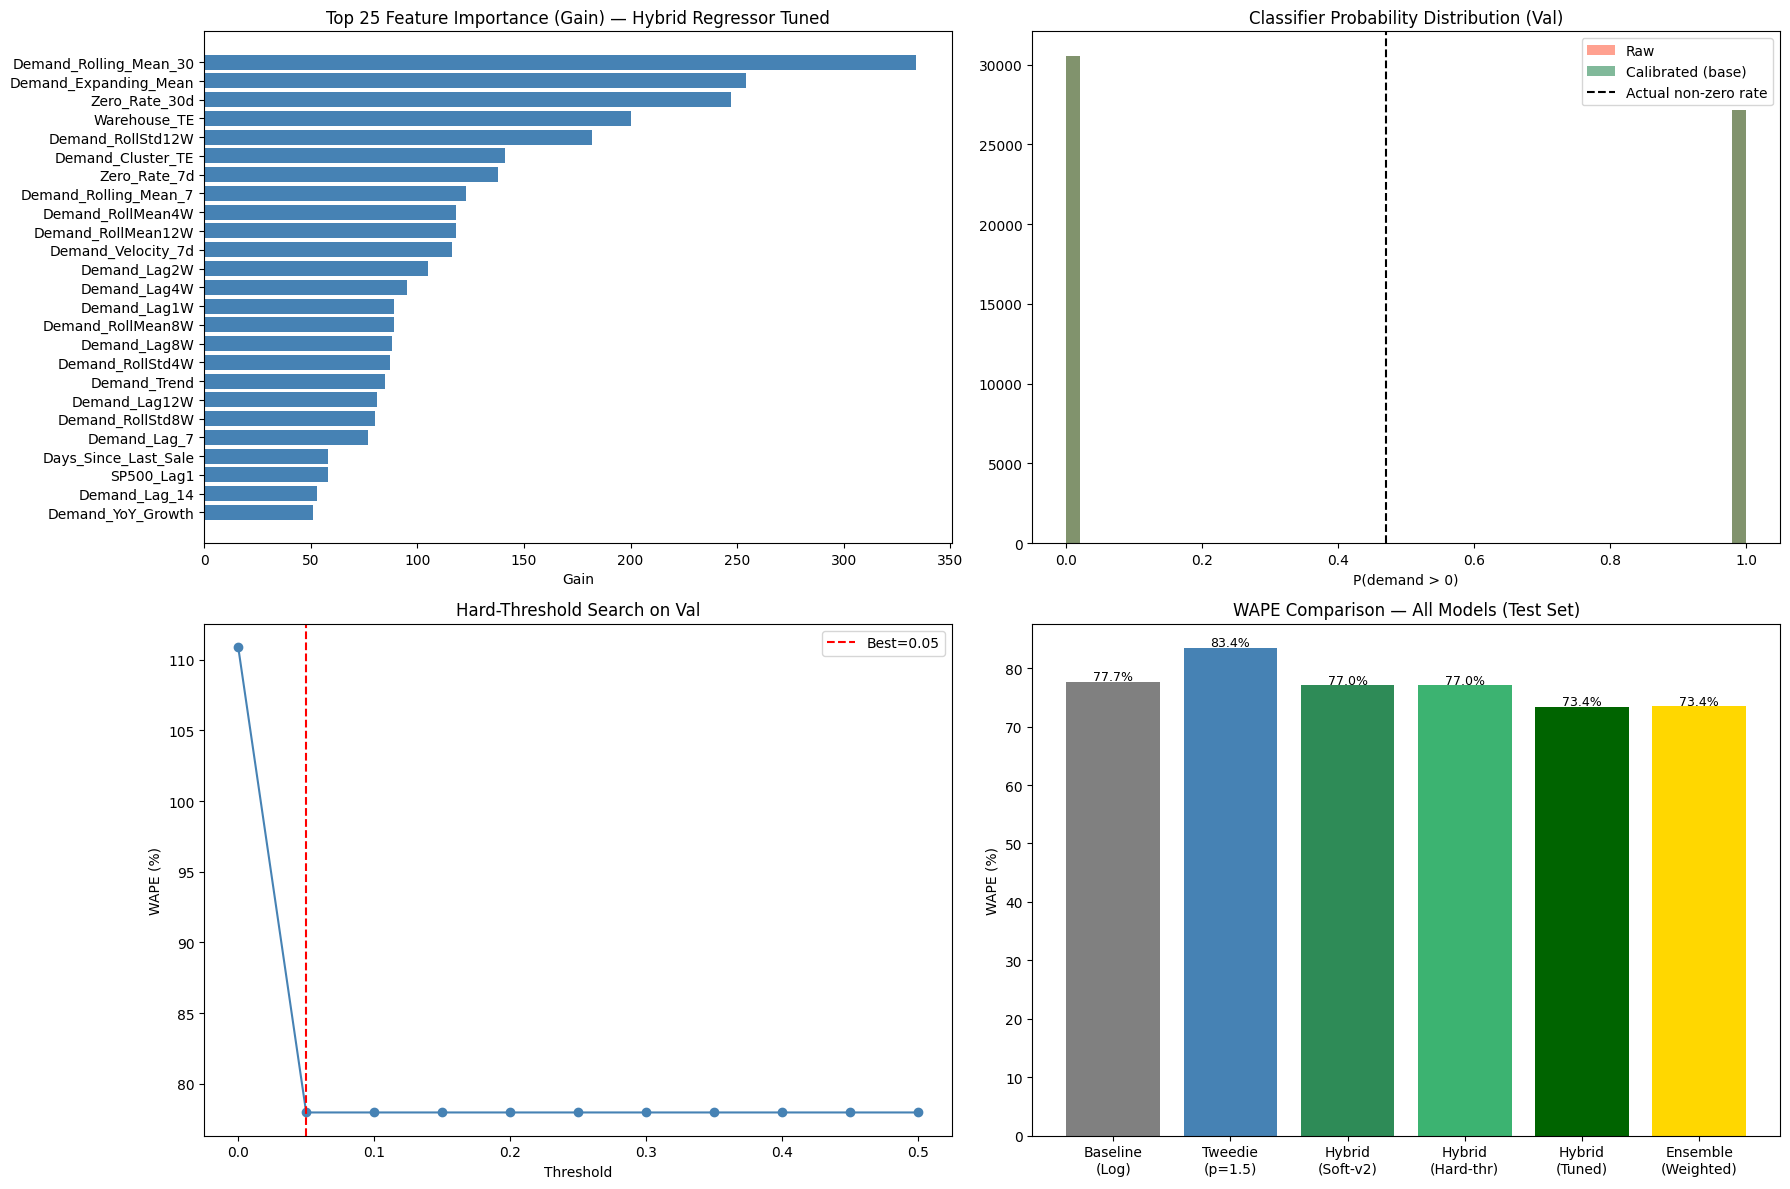

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Feature importance
top25 = importance_df.head(25)
axes[0, 0].barh(top25["feature"][::-1], top25["gain"][::-1], color="steelblue")
axes[0, 0].set_title("Top 25 Feature Importance (Gain) — Hybrid Regressor Tuned")
axes[0, 0].set_xlabel("Gain")

# 2. Probability calibration
axes[0, 1].hist(raw_probs_val, bins=50, alpha=0.6, label="Raw", color="tomato")
axes[0, 1].hist(cal_probs_val, bins=50, alpha=0.6, label="Calibrated (base)", color="seagreen")
axes[0, 1].axvline(x=(y_val > 0).mean(), color="black", linestyle="--", label="Actual non-zero rate")
axes[0, 1].set_title("Classifier Probability Distribution (Val)")
axes[0, 1].set_xlabel("P(demand > 0)")
axes[0, 1].legend()

# 3. Threshold search curve
val_wapes = []
for thr in thresholds:
    pv = np.where(cal_probs_val_test < thr, 0.0, raw_demand_val)
    val_wapes.append(wape_score(y_val.values, pv))
axes[1, 0].plot(thresholds, val_wapes, marker="o", color="steelblue")
axes[1, 0].axvline(x=best_threshold, color="red", linestyle="--", label=f"Best={best_threshold:.2f}")
axes[1, 0].set_title("Hard-Threshold Search on Val")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("WAPE (%)")
axes[1, 0].legend()

# 4. WAPE comparison
all_results_ordered = [
    ("Baseline\n(Log)", metrics_baseline["wape"]),
    ("Tweedie\n(p=1.5)", metrics_tweedie["wape"]),
    ("Hybrid\n(Soft-v2)", metrics_hybrid_soft["wape"]),
    ("Hybrid\n(Hard-thr)", metrics_hybrid_hard["wape"]),
    ("Hybrid\n(Tuned)", metrics_hybrid_tuned["wape"]),
    ("Ensemble\n(Weighted)", metrics_ensemble["wape"]),
]
model_names_viz = [x[0] for x in all_results_ordered]
wape_vals_viz = [x[1] for x in all_results_ordered]
colors_viz = ["gray", "steelblue", "seagreen", "mediumseagreen", "darkgreen", "gold"]
bars = axes[1, 1].bar(model_names_viz, wape_vals_viz, color=colors_viz)
axes[1, 1].set_title("WAPE Comparison — All Models (Test Set)")
axes[1, 1].set_ylabel("WAPE (%)")
for bar, val in zip(bars, wape_vals_viz):
    axes[1, 1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3, f"{val:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("analysis_v3.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# Final comparison

In [24]:
all_results = {
    "Baseline (Log Transform)":       metrics_baseline,
    "Tweedie (p=1.5, default)":       metrics_tweedie,
    "Hybrid (Soft-blend, base)":      metrics_hybrid_soft,
    f"Hybrid (Hard thr={best_threshold:.2f})": metrics_hybrid_hard,
    "Hybrid Tuned (Optuna)":          metrics_hybrid_tuned,
    f"Ensemble (w_hybrid={best_w:.2f})": metrics_ensemble,
}

base_wape = metrics_baseline["wape"]
print(f"\n  {'Model':<40s} {'RMSE':>10} {'MAE':>10} {'WAPE':>10} {'vs Baseline':>14}")
print(f"  {'-' * 86}")
for name, m in all_results.items():
    delta = (m["wape"] - base_wape) / base_wape * 100
    tag = f"{'↓' if delta < 0 else '↑'} {abs(delta):.1f}%" if name != "Baseline (Log Transform)" else "(base)"
    print(f"  {name:<40s} {m['rmse']:>10.2f} {m['mae']:>10.2f} {m['wape']:>9.2f}%  {tag:>14}")



  Model                                          RMSE        MAE       WAPE    vs Baseline
  --------------------------------------------------------------------------------------
  Baseline (Log Transform)                   22532.54    1624.52     77.66%          (base)
  Tweedie (p=1.5, default)                   20682.03    1744.71     83.41%          ↑ 7.4%
  Hybrid (Soft-blend, base)                  22238.16    1611.56     77.04%          ↓ 0.8%
  Hybrid (Hard thr=0.05)                     22238.16    1611.56     77.04%          ↓ 0.8%
  Hybrid Tuned (Optuna)                      19977.20    1535.71     73.42%          ↓ 5.5%
  Ensemble (w_hybrid=0.95)                   19955.63    1536.11     73.43%          ↓ 5.4%


# FEATURE SELECTION — Correlation Filter + Importance Threshold

In [25]:
CORR_THRESHOLD = 0.95
IMPORTANCE_PCT_THRESHOLD = 0.01   

# Combined importance
imp_clf = pd.Series(clf_tuned.feature_importances_, index=MODEL_FEATURES, dtype=float)
imp_reg = pd.Series(reg_tuned.feature_importances_, index=MODEL_FEATURES, dtype=float)

imp_clf_norm = imp_clf / imp_clf.max() if imp_clf.max() > 0 else imp_clf
imp_reg_norm = imp_reg / imp_reg.max() if imp_reg.max() > 0 else imp_reg
combined_importance = (imp_clf_norm + imp_reg_norm).sort_values(ascending=False)

print(f"\n Number of Features: {len(MODEL_FEATURES)}")

# Correlation Filter 
print(f"\n  Correlation filter (|corr| > {CORR_THRESHOLD})")
corr_matrix = X_train[MODEL_FEATURES].corr().abs()

to_drop_corr = set()
cols = corr_matrix.columns.tolist()
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        f1, f2 = cols[i], cols[j]
        if f1 in to_drop_corr or f2 in to_drop_corr:
            continue
        corr_val = corr_matrix.iloc[i, j]
        if corr_val > CORR_THRESHOLD: 
            weaker = f1 if combined_importance.get(f1, 0) < combined_importance.get(f2, 0) else f2
            stronger = f2 if weaker == f1 else f1
            to_drop_corr.add(weaker)
            print(f"    Drop '{weaker}' (corr={corr_val:.3f} voi '{stronger}', "
                  f"importance {combined_importance.get(weaker,0):.3f} < {combined_importance.get(stronger,0):.3f})")

print(f"\n  Drop {len(to_drop_corr)} feature because of high correlation.")

# Importance Threshold Filter 
remaining_after_corr = [c for c in MODEL_FEATURES if c not in to_drop_corr]
imp_threshold_val = combined_importance.max() * IMPORTANCE_PCT_THRESHOLD

to_drop_importance = [
    c for c in remaining_after_corr
    if combined_importance.get(c, 0) < imp_threshold_val
]
print(f"\n  Importance threshold filter (combined gain < {IMPORTANCE_PCT_THRESHOLD:.0%} of max)")
print(f"    Threshold value: {imp_threshold_val:.4f}")
for f in to_drop_importance:
    print(f"    Drop '{f}' (combined importance={combined_importance.get(f,0):.4f})")
print(f"\n  Drop {len(to_drop_importance)} feature because importance too low.")

SELECTED_FEATURES = [c for c in MODEL_FEATURES if c not in to_drop_corr and c not in to_drop_importance]

print(f"  {len(MODEL_FEATURES)} -> {len(SELECTED_FEATURES)} features "
      f"(Drop {len(MODEL_FEATURES) - len(SELECTED_FEATURES)})")
print(f"\n  Selected features:")
for i, f in enumerate(SELECTED_FEATURES):
    print(f"    {i+1:3d}. {f}")


# RETRAIN with Selected Features & comparing WAPE 
print("RETRAIN — Hybrid Tuned voi Selected Features")

X_train_sel = X_train[SELECTED_FEATURES]
X_val_sel   = X_val[SELECTED_FEATURES]
X_test_sel  = X_test[SELECTED_FEATURES]

clf_selected = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=bp["clf_lr"],
    max_depth=bp["clf_max_depth"],
    num_leaves=bp["clf_num_leaves"],
    min_child_samples=bp["clf_min_child"],
    subsample=bp["clf_subsample"],
    colsample_bytree=bp["clf_colsample"],
    reg_alpha=bp["clf_reg_alpha"],
    reg_lambda=bp["clf_reg_lambda"],
    is_unbalance=True,
    random_state=42, n_jobs=-1, verbosity=-1,
)
clf_selected.fit(
    X_train_sel, (y_train > 0).astype(int),
    eval_set=[(X_val_sel, (y_val > 0).astype(int))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)
cal_selected = CalibratedClassifierCV(clf_selected, cv="prefit", method="isotonic")
cal_selected.fit(X_val_sel, (y_val > 0).astype(int))

reg_selected = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=bp["reg_lr"],
    max_depth=bp["reg_max_depth"],
    num_leaves=bp["reg_num_leaves"],
    min_child_samples=bp["reg_min_child"],
    subsample=bp["reg_subsample"],
    colsample_bytree=bp["reg_colsample"],
    reg_alpha=bp["reg_reg_alpha"],
    reg_lambda=bp["reg_reg_lambda"],
    random_state=42, n_jobs=-1, verbosity=-1,
)
reg_selected.fit(
    X_train_sel[nonzero_tr], log_transform(y_train[nonzero_tr].values),
    eval_set=[(X_val_sel[nonzero_val], log_transform(y_val[nonzero_val].values))],
    callbacks=[lgb.early_stopping(50, verbose=False)],
)

probs_selected_test = cal_selected.predict_proba(X_test_sel)[:, 1]
demand_selected_test = inverse_log_transform(reg_selected.predict(X_test_sel))
preds_selected = np.where(probs_selected_test < best_threshold_optuna, 0.0, demand_selected_test)
metrics_selected = compute_metrics(y_test, preds_selected, label="Hybrid (Selected Features)")

print(f"\n  {'Model':<35s} {'#Features':>10} {'RMSE':>10} {'MAE':>10} {'WAPE':>10}")
print(f"  {'Hybrid Tuned (Full features)':<35s} {len(MODEL_FEATURES):>10} "
      f"{metrics_hybrid_tuned['rmse']:>10.2f} {metrics_hybrid_tuned['mae']:>10.2f} {metrics_hybrid_tuned['wape']:>9.2f}%")
print(f"  {'Hybrid (Selected Features)':<35s} {len(SELECTED_FEATURES):>10} "
      f"{metrics_selected['rmse']:>10.2f} {metrics_selected['mae']:>10.2f} {metrics_selected['wape']:>9.2f}%")

delta_wape = metrics_selected["wape"] - metrics_hybrid_tuned["wape"]
print(f"\n  Delta WAPE (Selected - Full): {delta_wape:+.2f}pp")
if delta_wape <= 0.3:
    print("  [OK] Feature selection still keep performance/improve with less feature => Recommended.")
elif delta_wape <= 1.0:
    print("  [WARN] WAPE slightly rise — some important features have been eliminated => Need to consider.")
else:
    print("  [FAIL] WAPE rise — features are really important have been eliminated. Should retrain.")

with open("selected_features.json", "w") as f:
    json.dump({
        "selected_features": SELECTED_FEATURES,
        "dropped_correlation": sorted(to_drop_corr),
        "dropped_low_importance": to_drop_importance,
        "wape_full": metrics_hybrid_tuned["wape"],
        "wape_selected": metrics_selected["wape"],
    }, f, indent=2, ensure_ascii=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(["Full\nFeatures", "Selected\nFeatures"],
            [len(MODEL_FEATURES), len(SELECTED_FEATURES)], color=["steelblue", "seagreen"])
axes[0].set_title("Number of Features")
axes[0].set_ylabel("Count")
for i, v in enumerate([len(MODEL_FEATURES), len(SELECTED_FEATURES)]):
    axes[0].text(i, v + 1, str(v), ha="center")

axes[1].bar(["Full\nFeatures", "Selected\nFeatures"],
            [metrics_hybrid_tuned["wape"], metrics_selected["wape"]], color=["steelblue", "seagreen"])
axes[1].set_title("WAPE on Test Set")
axes[1].set_ylabel("WAPE (%)")
for i, v in enumerate([metrics_hybrid_tuned["wape"], metrics_selected["wape"]]):
    axes[1].text(i, v + 0.3, f"{v:.2f}%", ha="center")

plt.tight_layout()
plt.savefig("feature_selection_comparison.png", dpi=150, bbox_inches="tight")
plt.close()




 Number of Features: 65

  Correlation filter (|corr| > 0.95)
    Drop 'Crude_Oil_WTI_Lag1' (corr=1.000 voi 'Oil_Price_Lag1', importance 0.027 < 0.063)
    Drop 'Industrial_ETF_Lag1' (corr=0.995 voi 'SP500_Lag1', importance 0.087 < 0.273)
    Drop 'Year' (corr=0.953 voi 'SP500_Lag1', importance 0.000 < 0.273)
    Drop 'Treasury_10Y_Lag1' (corr=0.999 voi 'Yield_Spread_Lag1', importance 0.018 < 0.039)
    Drop 'WeekOfYear' (corr=1.000 voi 'Week_Of_Year', importance 0.021 < 0.102)
    Drop 'Quarter' (corr=0.971 voi 'Month', importance 0.000 < 0.001)
    Drop 'Month' (corr=0.997 voi 'DayOfYear', importance 0.001 < 0.071)
    Drop 'Month_Sin' (corr=0.981 voi 'Week_Sin', importance 0.002 < 0.043)
    Drop 'Month_Cos' (corr=0.978 voi 'Week_Cos', importance 0.009 < 0.034)
    Drop 'Demand_RollMean8W' (corr=0.970 voi 'Demand_RollMean12W', importance 0.268 < 0.357)
    Drop 'Consecutive_Zeros' (corr=1.000 voi 'Weeks_Since_Last_Order', importance 0.009 < 0.189)
    Drop 'Has_YoY_Data' (corr=0.98

In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
np.random.seed(42)

#Val/Test Gap Analysis

THRESHOLD_OPTUNA = 0.153
THRESHOLD_VAL    = 0.05
VAL_WAPE_REPORTED = 74.89

# Predictions on Val with Hybrid Tuned
probs_tuned_val = cal_tuned.predict_proba(X_val)[:, 1]
demand_tuned_val = inverse_log_transform(reg_tuned.predict(X_val))

# Predictions on Test with Hybrid Tuned
probs_tuned_test = cal_tuned.predict_proba(X_test)[:, 1]
demand_tuned_test = inverse_log_transform(reg_tuned.predict(X_test))

# Apply threshold from Optuna
preds_val_optuna_thr  = np.where(probs_tuned_val  < THRESHOLD_OPTUNA, 0.0, demand_tuned_val)
preds_test_optuna_thr = np.where(probs_tuned_test < THRESHOLD_OPTUNA, 0.0, demand_tuned_test)

if "compute_metrics_full" not in globals():
    compute_metrics_full = compute_metrics

m_val_opt = compute_metrics_full(y_val, preds_val_optuna_thr)
m_test_opt = compute_metrics_full(y_test, preds_test_optuna_thr)

gap_wape = m_test_opt["wape"] - m_val_opt["wape"]

print(f"\n  [Threshold = {THRESHOLD_OPTUNA}]")
val_zero_pred = m_val_opt.get("zero_pred_rate", m_val_opt.get("zero_pred_pct", 0.0))
print(f"  Val  WAPE = {m_val_opt['wape']:.2f}%  (zero_pred={val_zero_pred:.1f}%)")
test_zero_pred = m_test_opt.get("zero_pred_rate", m_test_opt.get("zero_pred_pct", 0.0))
print(f"  Test WAPE = {m_test_opt['wape']:.2f}%  (zero_pred={test_zero_pred:.1f}%)")
print(f"  Gap (Test - Val) = {gap_wape:+.2f}%")

LOWER_BOUND, UPPER_BOUND = 75.0, 76.5
if LOWER_BOUND <= m_test_opt["wape"] <= UPPER_BOUND:
    verdict = "PASS - Model generalizes well (Test WAPE in target range)"
elif m_test_opt["wape"] < LOWER_BOUND:
    verdict = "BETTER THAN EXPECTED — Test WAPE below target"
elif gap_wape <= 3.0:
    verdict = "MARGINAL - Small gap but Test WAPE slightly above target"
else:
    verdict = "FAIL - Overfitting or distribution shift remains"
print(f"\n  Verdict: {verdict}")


preds_test_val_thr = np.where(probs_tuned_test < THRESHOLD_VAL, 0.0, demand_tuned_test)
m_test_val_thr = compute_metrics_full(y_test, preds_test_val_thr)

# Sweep thresholds for reference
sweep_thresholds = np.round(np.arange(0.00, 0.51, 0.01), 2)
sweep_results = []
for thr in sweep_thresholds:
    p = np.where(probs_tuned_test < thr, 0.0, demand_tuned_test)
    w = wape_score(y_test.values, p)
    zpred = (p == 0).mean() * 100
    sweep_results.append({"threshold": thr, "test_wape": w, "zero_pred_pct": zpred})
sweep_df = pd.DataFrame(sweep_results)

print(f"\n  {'Threshold':<15} {'RMSE':>10} {'MAE':>10} {'WAPE':>10} {'Zero Pred%':>12}")

for thr, m, name in [
    (THRESHOLD_OPTUNA, m_test_opt, "Optuna (0.153)"),
    (THRESHOLD_VAL,    m_test_val_thr, "Val search (0.05)"),
]:
    zero_pred = m.get("zero_pred_rate", m.get("zero_pred_pct", 0.0))
    print(f"  {name:<15} {m['rmse']:>10.2f} {m['mae']:>10.2f} "
          f"{m['wape']:>9.2f}%  {zero_pred:>10.1f}%")

best_row = sweep_df.loc[sweep_df["test_wape"].idxmin()]
print(f"\n  [Reference] Best threshold on Test: "
      f"{best_row['threshold']:.2f}  (Test WAPE={best_row['test_wape']:.2f}%)")
print(f"  Distance to best: "
      f"0.153 off by {m_test_opt['wape'] - best_row['test_wape']:+.2f}%  |  "
      f"0.05 off by {m_test_val_thr['wape'] - best_row['test_wape']:+.2f}%")


fi_clf = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "gain_clf": clf_tuned.feature_importances_,
}).sort_values("gain_clf", ascending=False).reset_index(drop=True)

fi_reg = pd.DataFrame({
    "feature": MODEL_FEATURES,
    "gain_reg": reg_tuned.feature_importances_,
}).sort_values("gain_reg", ascending=False).reset_index(drop=True)

fi_merged = fi_clf.rename(columns={"gain_clf": "gain"}).copy()
fi_merged["rank_clf"] = fi_merged.index + 1
fi_merged = fi_merged.merge(
    fi_reg[["feature", "gain_reg"]].assign(
        rank_reg=fi_reg.reset_index().index + 1
    ),
    on="feature", how="left"
)
fi_merged["rank_delta"] = fi_merged["rank_reg"] - fi_merged["rank_clf"]

INTERMITTENT_FEATURES = [
    "Days_Since_Last_Sale", "Consecutive_Zeros",
    "Zero_Rate_7d", "Zero_Rate_30d", "Demand_Velocity_7d"
]
TE_FEATURES = [c for c in MODEL_FEATURES if c.endswith("_TE")]

print("\n  Intermittent features rank (Classifier vs Regressor)")
print(f"  {'Feature':<30} {'Rank CLF':>10} {'Rank REG':>10} {'Gain CLF':>12} {'Gain REG':>12}")

for feat in INTERMITTENT_FEATURES:
    row = fi_merged[fi_merged["feature"] == feat]
    if row.empty:
        print(f"  {feat:<30}  NOT FOUND")
        continue
    r = row.iloc[0]
    print(f"  {feat:<30} {int(r['rank_clf']):>10} {int(r['rank_reg']):>10} "
          f"{r['gain']:>12.1f} {r['gain_reg']:>12.1f}")

print("\n  Target Encoding features (influence after leakage fix)")
print(f"  {'Feature':<30} {'Rank CLF':>10} {'Rank REG':>10} {'Gain CLF':>12} {'Gain REG':>12}")
for feat in TE_FEATURES:
    row = fi_merged[fi_merged["feature"] == feat]
    if row.empty:
        continue
    r = row.iloc[0]
    flag = " HIGH" if (r["rank_clf"] <= 5 or r["rank_reg"] <= 5) else ""
    print(f"  {feat:<30} {int(r['rank_clf']):>10} {int(r['rank_reg']):>10} "
          f"{r['gain']:>12.1f} {r['gain_reg']:>12.1f}  {flag}")


    RMSE=21728.00  MAE=1535.01  MAPE=153.2%  WAPE=75.0%
    RMSE=19977.20  MAE=1535.71  MAPE=153.6%  WAPE=73.4%

  [Threshold = 0.153]
  Val  WAPE = 75.00%  (zero_pred=0.0%)
  Test WAPE = 73.42%  (zero_pred=0.0%)
  Gap (Test - Val) = -1.59%

  Verdict: BETTER THAN EXPECTED — Test WAPE below target
    RMSE=19977.20  MAE=1535.71  MAPE=153.6%  WAPE=73.4%

  Threshold             RMSE        MAE       WAPE   Zero Pred%
  Optuna (0.153)    19977.20    1535.71     73.42%         0.0%
  Val search (0.05)   19977.20    1535.71     73.42%         0.0%

  [Reference] Best threshold on Test: 0.01  (Test WAPE=73.42%)
  Distance to best: 0.153 off by +0.00%  |  0.05 off by +0.00%

  Intermittent features rank (Classifier vs Regressor)
  Feature                          Rank CLF   Rank REG     Gain CLF     Gain REG
  Days_Since_Last_Sale                    7         22         33.0         58.0
  Consecutive_Zeros                      18         65          8.0          0.0
  Zero_Rate_7d          